# Titanic Survival Prediction Challenge
## Complete End-to-End Machine Learning Pipeline

### Author: Shivam Singh
### Competition: Titanic - Machine Learning from Disaster
### Platform: Kaggle

This notebook demonstrates a complete machine learning workflow including:

- Data Loading
- Exploratory Data Analysis (EDA)
- Data Cleaning
- Feature Engineering
- Model Building
- Hyperparameter Tuning
- Ensemble Learning
- Final Submission Generation

In [1]:
# ================================
# INSTALL REQUIRED LIBRARIES
# ================================

! pip install xgboost lightgbm seaborn scikit-learn matplotlib pandas numpy --quiet


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Verify Library Installation

This section verifies that all libraries are installed successfully and ready for use.

In [2]:
# ================================
# BASIC LIBRARIES
# ================================

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# ================================
# MACHINE LEARNING
# ================================

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)

from sklearn.svm import SVC

# XGBoost
from xgboost import XGBClassifier

# LightGBM
from lightgbm import LGBMClassifier

# Dataset Loading

In this section, we load the Titanic training and testing datasets.

In [3]:
# Load datasets
train_df = pd.read_csv("titanic/train.csv")
test_df = pd.read_csv("titanic/test.csv")

# Display shape
print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (891, 12)
Test Shape: (418, 11)


# Dataset Preview

Understanding the structure and contents of the dataset.

In [4]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Missing Values Analysis

We analyze missing values present in the dataset.

In [7]:
missing = train_df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

Cabin       687
Age         177
Embarked      2
dtype: int64

# Dataset Information Analysis

From the dataset inspection, we observe:

- Total training samples: **891**
- Total features: **12**
- Dataset contains:
  - Numerical features
  - Categorical features
  - Missing values

## Missing Values Summary

| Feature | Missing Values |
|----------|----------------|
| Cabin    | 687            |
| Age      | 177            |
| Embarked | 2              |

## Observations

### 1. Cabin Feature
- Cabin contains a very high number of missing values.
- Instead of removing it completely, we can:
  - Create a new feature called `Deck`
  - Extract the first character from cabin values
  - Replace missing values with `"Unknown"`

### 2. Age Feature
- Age is an important survival-related feature.
- Missing values will be filled using:
  - Median imputation

### 3. Embarked Feature
- Only 2 missing values are present.
- These can be filled using:
  - Mode (most frequent value)

The next section performs preprocessing and missing value handling.

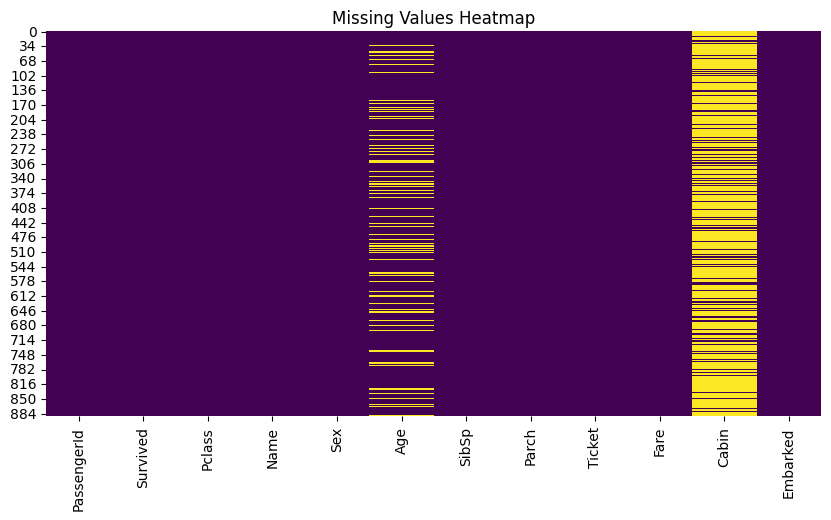

In [9]:
# ================================
# VISUALIZE MISSING VALUES
# ================================

plt.figure(figsize=(10,5))

sns.heatmap(
    train_df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.show()

# Missing Value Handling Strategy

We apply the following preprocessing strategy:

| Feature | Strategy |
|----------|-----------|
| Age | Fill using Median |
| Embarked | Fill using Mode |
| Cabin | Replace with "Unknown" |

# Understanding the Cabin Missing Value Problem

The `Cabin` feature contains:

- Total rows: **891**
- Missing values: **687**
- Available values: **204**

This means approximately:

:contentReference[oaicite:0]{index=0}

of the cabin data is missing.

## Important Observation

Since more than 75% of the values are missing, using simple imputation methods such as:

- Mean
- Median
- Mode

is NOT a good strategy for the `Cabin` column.

Cabin values are categorical and highly unique, for example:

- B96 B98
- C23 C25 C27
- G6

Filling all missing values with a single cabin value would create unrealistic patterns and heavily bias the model.

---

# Recommended Strategy for Cabin Feature

Instead of filling cabin numbers directly, we use:

## Option 1 (Recommended)
### Extract Deck Information

Example:

| Cabin | Deck |
|------|------|
| C85 | C |
| B96 B98 | B |
| G6 | G |
| Missing | U |

This preserves useful information while reducing noise.

---

# Implementation

In [12]:
train_df['Cabin'].mode()

0        B96 B98
1    C23 C25 C27
2             G6
Name: Cabin, dtype: str

In [13]:
# ================================
# HANDLE AGE MISSING VALUES
# ================================

train_df["Age"] = train_df["Age"].fillna(
    train_df["Age"].median()
)

# ================================
# HANDLE EMBARKED MISSING VALUES
# ================================

train_df["Embarked"] = train_df["Embarked"].fillna(
    train_df["Embarked"].mode()[0]
)

# ================================
# HANDLE CABIN MISSING VALUES
# ================================

# ================================
# FILL MISSING CABIN VALUES
# ================================

train_df["Cabin"] = train_df["Cabin"].fillna("Unknown")

# ================================
# EXTRACT DECK FEATURE
# ================================

train_df["Deck"] = train_df["Cabin"].str[0]

In [14]:
# View deck distribution

train_df["Deck"].value_counts()

Deck
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

In [15]:

# ================================
# REPLACE RARE DECK VALUES
# ================================

train_df["Deck"] = train_df["Deck"].replace(
    ["G", "T"],
    "Rare"
)

In [16]:
# Check updated deck counts

train_df["Deck"].value_counts()

Deck
U       687
C        59
B        47
D        33
E        32
A        15
F        13
Rare      5
Name: count, dtype: int64

In [17]:
train_df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
Deck           0
dtype: int64

# Exploratory Data Analysis (EDA)

After handling missing values, the next step is to perform Exploratory Data Analysis (EDA).

EDA helps us:

- Understand passenger survival patterns
- Identify important features
- Discover relationships between variables
- Detect trends and anomalies
- Build intuition before model development

In this section, we analyze:

1. Survival Distribution
2. Gender vs Survival
3. Passenger Class vs Survival
4. Age Distribution
5. Fare Distribution
6. Correlation Analysis
7. Family Relationships
8. Embarkation Analysis

# Survival Count Analysis

We first analyze how many passengers survived and how many did not survive.

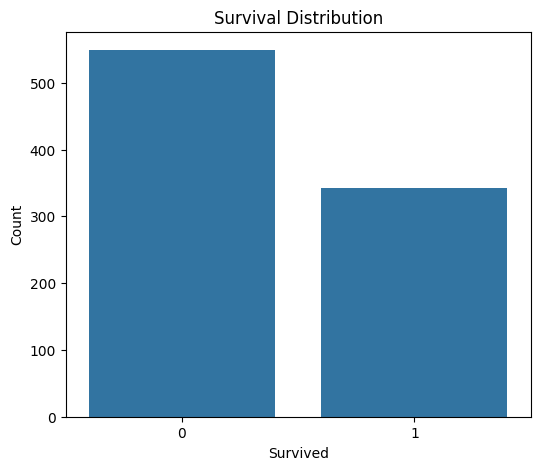

In [18]:
# ================================
# SURVIVAL DISTRIBUTION
# ================================

plt.figure(figsize=(6,5))

sns.countplot(
    x="Survived",
    data=train_df
)

plt.title("Survival Distribution")

plt.xlabel("Survived")
plt.ylabel("Count")

plt.show()

# Observation

- 0 = Did Not Survive
- 1 = Survived

The dataset is slightly imbalanced, with more passengers not surviving.

# Gender vs Survival Analysis

We analyze whether gender affected survival probability.

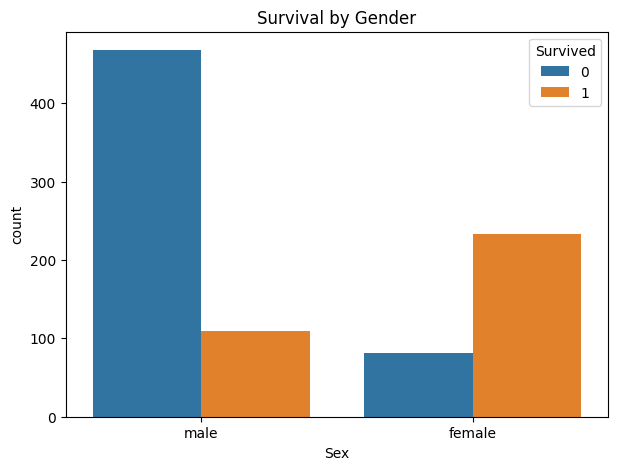

In [19]:
# ================================
# SURVIVAL BY GENDER
# ================================

plt.figure(figsize=(7,5))

sns.countplot(
    x="Sex",
    hue="Survived",
    data=train_df
)

plt.title("Survival by Gender")

plt.show()

# Observation

Female passengers had a significantly higher survival rate compared to male passengers.

This indicates that gender is a very important predictive feature.

# Passenger Class vs Survival

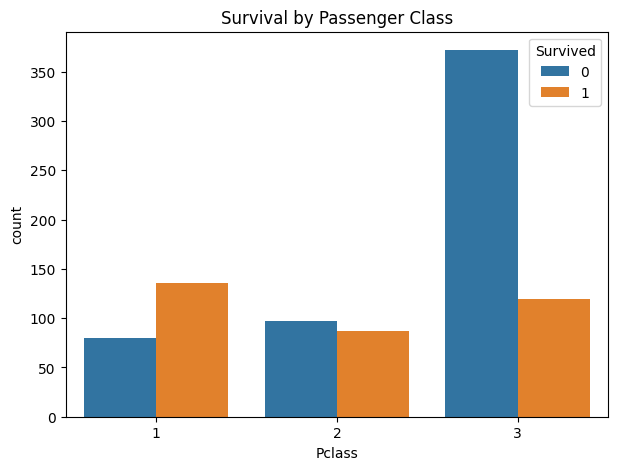

In [20]:
# ================================
# SURVIVAL BY PASSENGER CLASS
# ================================

plt.figure(figsize=(7,5))

sns.countplot(
    x="Pclass",
    hue="Survived",
    data=train_df
)

plt.title("Survival by Passenger Class")

plt.show()

# Age Distribution Analysis

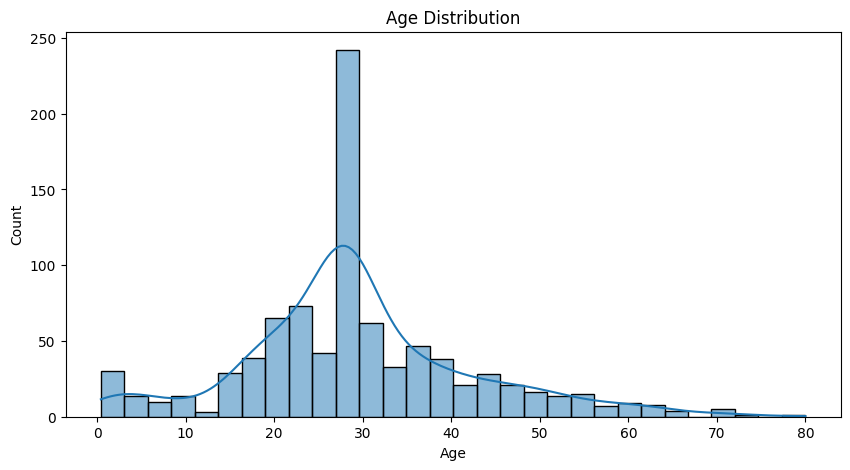

In [21]:
# ================================
# AGE DISTRIBUTION
# ================================

plt.figure(figsize=(10,5))

sns.histplot(
    train_df["Age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.show()

# Observation

- Most passengers were between 20–40 years old.
- Children and elderly passengers were fewer in number.

# Age vs Survival Analysis

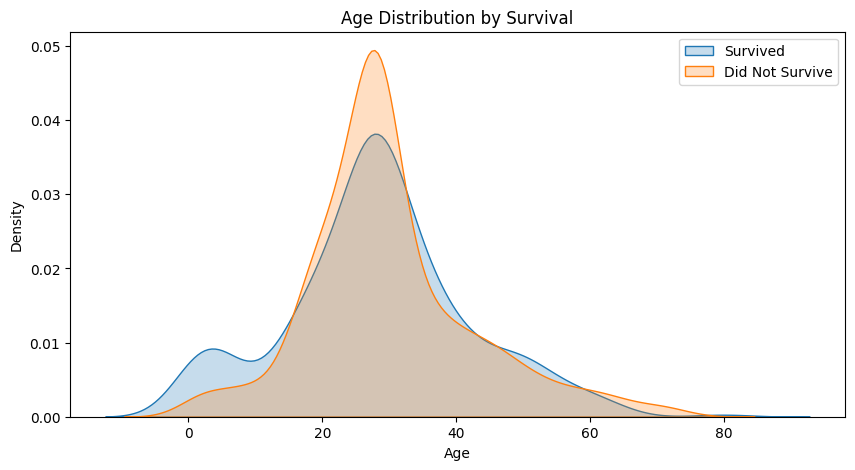

In [22]:
# ================================
# AGE VS SURVIVAL
# ================================

plt.figure(figsize=(10,5))

sns.kdeplot(
    train_df[train_df["Survived"] == 1]["Age"],
    label="Survived",
    fill=True
)

sns.kdeplot(
    train_df[train_df["Survived"] == 0]["Age"],
    label="Did Not Survive",
    fill=True
)

plt.title("Age Distribution by Survival")

plt.legend()

plt.show()

# Observation

Children had relatively higher survival rates compared to some adult age groups.

# Fare Distribution

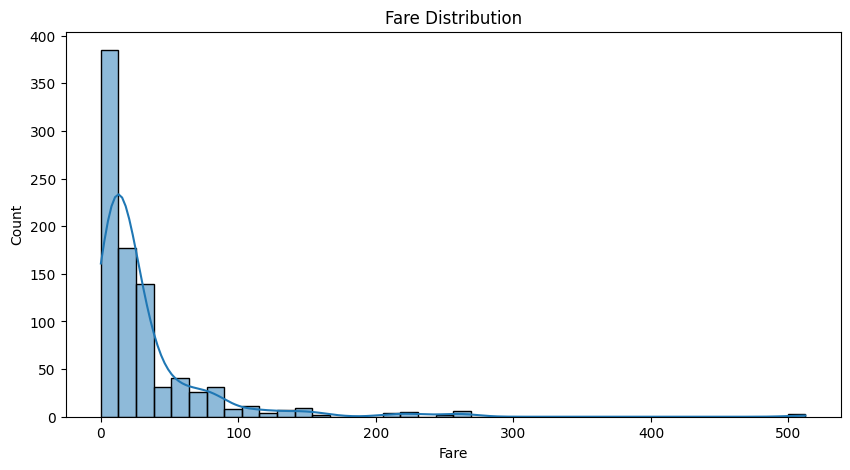

In [23]:
# ================================
# FARE DISTRIBUTION
# ================================

plt.figure(figsize=(10,5))

sns.histplot(
    train_df["Fare"],
    bins=40,
    kde=True
)

plt.title("Fare Distribution")

plt.show()

# Observation

Fare values are highly skewed with several outliers.

# Embarkation Port Analysis

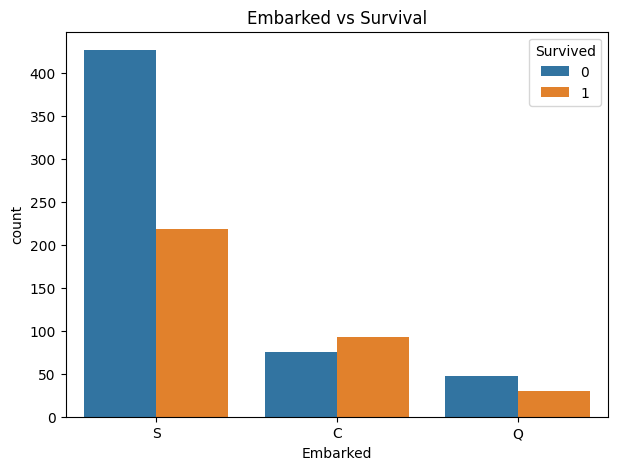

In [24]:
# ================================
# EMBARKED VS SURVIVAL
# ================================

plt.figure(figsize=(7,5))

sns.countplot(
    x="Embarked",
    hue="Survived",
    data=train_df
)

plt.title("Embarked vs Survival")

plt.show()

# Observation

Survival patterns differ across embarkation ports.

# Family Size Feature Creation

In [25]:
# ================================
# CREATE FAMILY SIZE FEATURE
# ================================

train_df["FamilySize"] = (
    train_df["SibSp"] +
    train_df["Parch"] + 1
)

train_df[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


# Family Size vs Survival

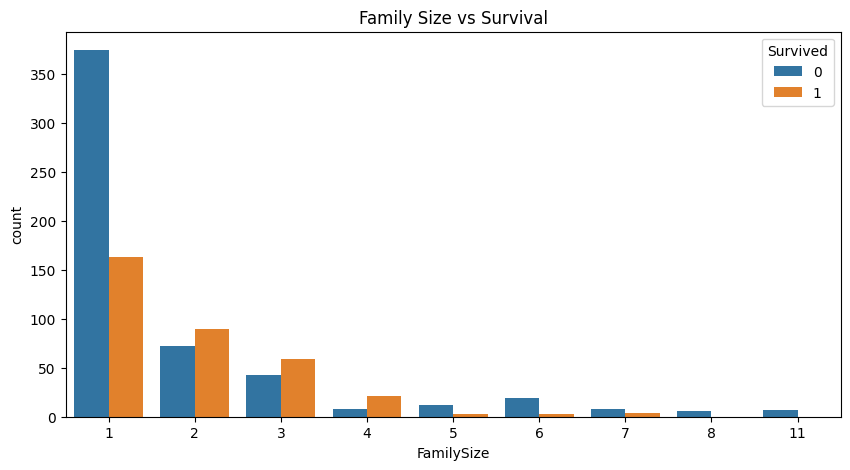

In [26]:
# ================================
# FAMILY SIZE VS SURVIVAL
# ================================

plt.figure(figsize=(10,5))

sns.countplot(
    x="FamilySize",
    hue="Survived",
    data=train_df
)

plt.title("Family Size vs Survival")

plt.show()

# Correlation Analysis

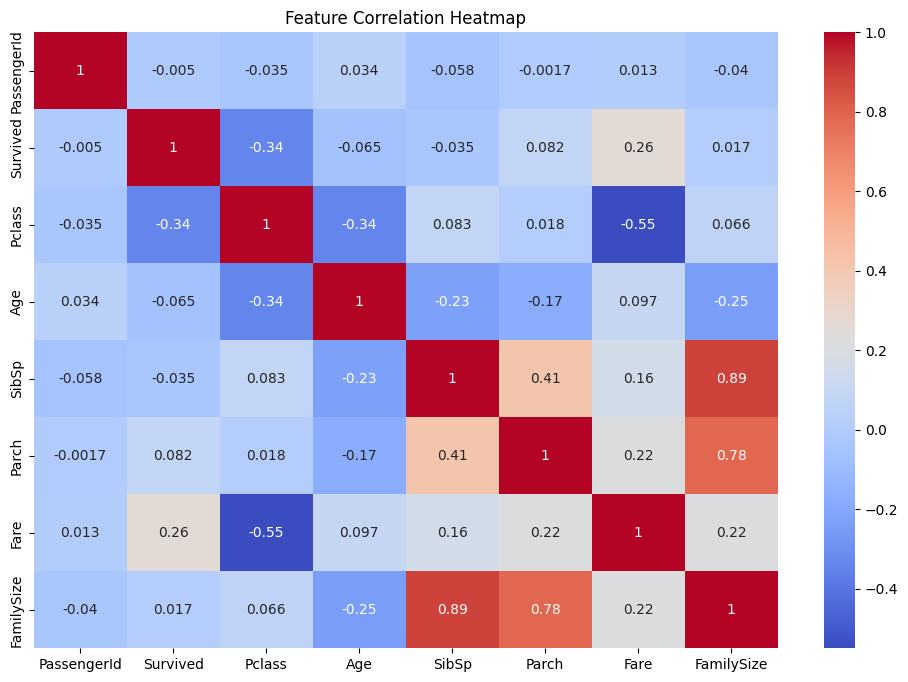

In [27]:
# ================================
# CORRELATION HEATMAP
# ================================

numeric_df = train_df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

# Observation

Key observations:

- Fare positively correlates with survival.
- Passenger class negatively correlates with survival.
- Family-related features show moderate relationships.

# Outlier Detection

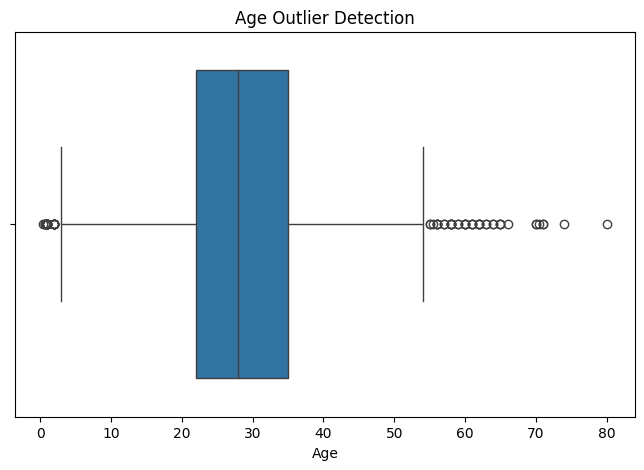

In [28]:
# ================================
# BOXPLOT FOR AGE
# ================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x=train_df["Age"]
)

plt.title("Age Outlier Detection")

plt.show()

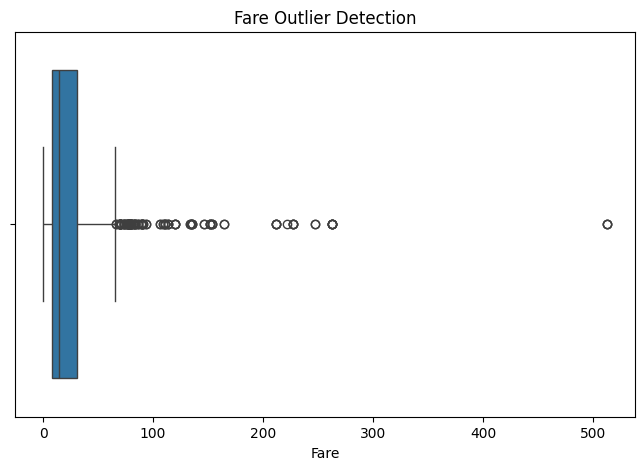

In [29]:
# ================================
# BOXPLOT FOR FARE
# ================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x=train_df["Fare"]
)

plt.title("Fare Outlier Detection")

plt.show()

# EDA Summary

Important findings from Exploratory Data Analysis:

1. Female passengers had higher survival rates.
2. First-class passengers survived more frequently.
3. Fare is positively associated with survival.
4. Family size influences survival probability.
5. Age distributions vary across survival groups.
6. Missing cabin information itself may contain predictive value.

The insights from EDA will guide:

- Feature Engineering
- Model Selection
- Hyperparameter Tuning
- Ensemble Learning

# Feature Engineering

Feature Engineering is one of the most important steps in machine learning.

The goal is to create new meaningful features from existing data that can improve model performance.

In this section, we will create:

1. Title Feature
2. IsAlone Feature
3. Age Groups
4. Fare Groups
5. Ticket Frequency
6. Interaction Features

These engineered features help models better understand hidden survival patterns.

# Title Extraction from Name

Passenger names contain useful social information such as:

- Mr
- Mrs
- Miss
- Master
- Dr

Titles can strongly influence survival probability.

In [30]:
# ================================
# EXTRACT TITLE FROM NAME
# ================================

train_df["Title"] = train_df["Name"].str.extract(
    ' ([A-Za-z]+)\.',
    expand=False
)

train_df["Title"].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

# Group Rare Titles

Some titles occur very infrequently.

To reduce noise and improve generalization,
rare titles are grouped into a single category called "Rare".

In [31]:
# ================================
# REPLACE RARE TITLES
# ================================

train_df["Title"] = train_df["Title"].replace(
    [
        'Lady',
        'Countess',
        'Capt',
        'Col',
        'Don',
        'Dr',
        'Major',
        'Rev',
        'Sir',
        'Jonkheer',
        'Dona'
    ],
    'Rare'
)

train_df["Title"] = train_df["Title"].replace(
    ['Mlle', 'Ms'],
    'Miss'
)

train_df["Title"] = train_df["Title"].replace(
    'Mme',
    'Mrs'
)

In [32]:
# View updated title counts

train_df["Title"].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

# Title vs Survival Analysis

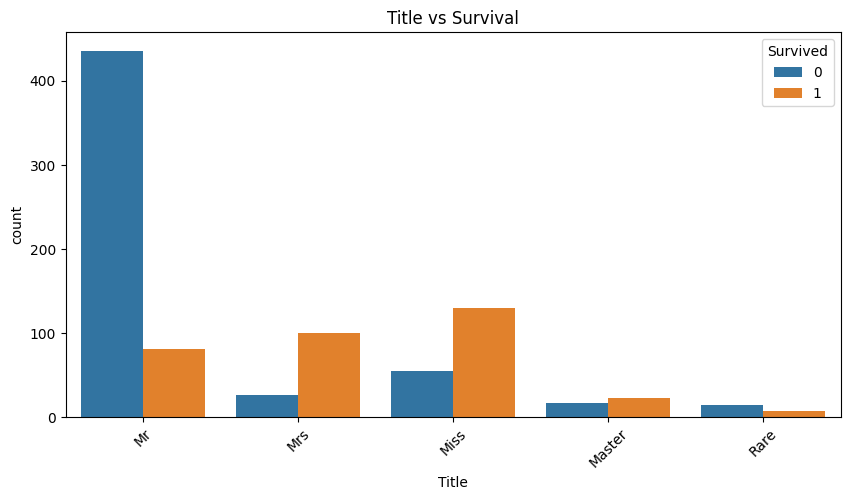

In [33]:
# ================================
# TITLE VS SURVIVAL
# ================================

plt.figure(figsize=(10,5))

sns.countplot(
    x="Title",
    hue="Survived",
    data=train_df
)

plt.title("Title vs Survival")

plt.xticks(rotation=45)

plt.show()

# IsAlone Feature

Passengers traveling alone may have different survival probabilities compared to passengers traveling with family members.

In [34]:
# ================================
# CREATE ISALONE FEATURE
# ================================

train_df["IsAlone"] = 0

train_df.loc[
    train_df["FamilySize"] == 1,
    "IsAlone"
] = 1

In [35]:
# View IsAlone counts

train_df["IsAlone"].value_counts()

IsAlone
1    537
0    354
Name: count, dtype: int64

# Survival Analysis for IsAlone Feature

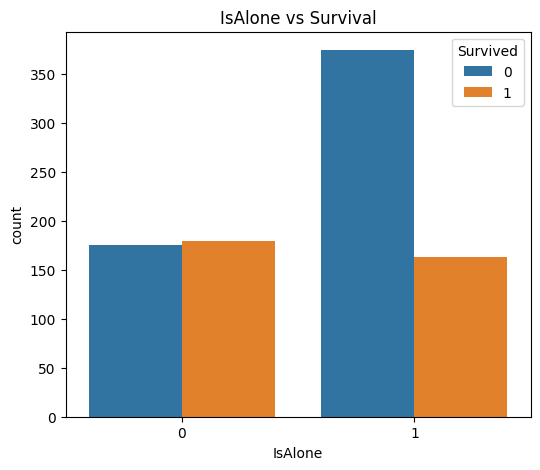

In [36]:
# ================================
# ISALONE VS SURVIVAL
# ================================

plt.figure(figsize=(6,5))

sns.countplot(
    x="IsAlone",
    hue="Survived",
    data=train_df
)

plt.title("IsAlone vs Survival")

plt.show()

# Age Group Feature

Grouping age into categories helps models capture non-linear age relationships.

In [37]:
# ================================
# CREATE AGE GROUPS
# ================================

train_df["AgeGroup"] = pd.cut(
    train_df["Age"],
    bins=[0,12,20,40,60,80],
    labels=[
        "Child",
        "Teen",
        "Adult",
        "MiddleAge",
        "Senior"
    ]
)

train_df["AgeGroup"].value_counts()

AgeGroup
Adult        562
MiddleAge    128
Teen         110
Child         69
Senior        22
Name: count, dtype: int64

# Age Group vs Survival

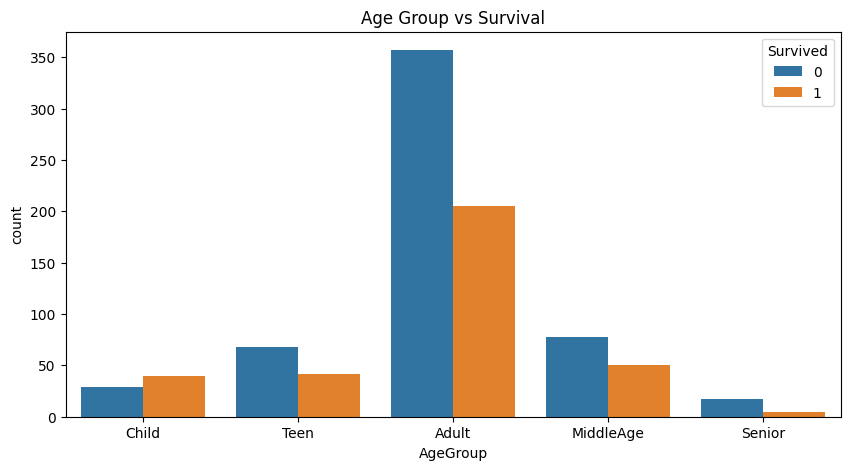

In [38]:
# ================================
# AGE GROUP VS SURVIVAL
# ================================

plt.figure(figsize=(10,5))

sns.countplot(
    x="AgeGroup",
    hue="Survived",
    data=train_df
)

plt.title("Age Group vs Survival")

plt.show()

# Fare Group Feature

Ticket fare can indicate passenger economic status.

In [39]:
# ================================
# CREATE FARE GROUPS
# ================================

train_df["FareGroup"] = pd.qcut(
    train_df["Fare"],
    4,
    labels=[
        "Low",
        "Medium",
        "High",
        "VeryHigh"
    ]
)

train_df["FareGroup"].value_counts()

FareGroup
Medium      224
Low         223
High        222
VeryHigh    222
Name: count, dtype: int64

# Fare Group vs Survival

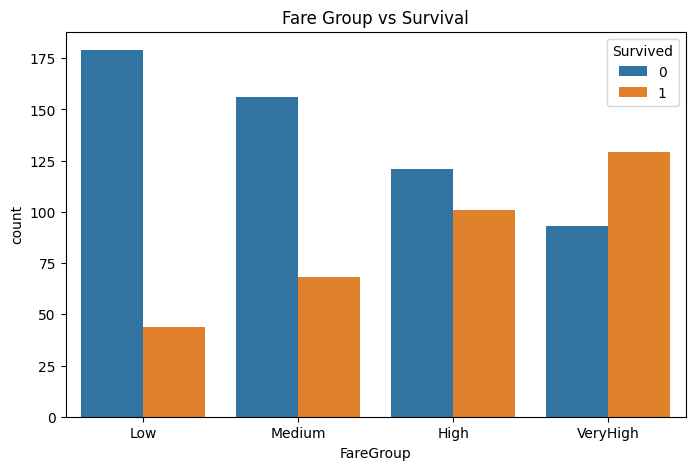

In [40]:
# ================================
# FARE GROUP VS SURVIVAL
# ================================

plt.figure(figsize=(8,5))

sns.countplot(
    x="FareGroup",
    hue="Survived",
    data=train_df
)

plt.title("Fare Group vs Survival")

plt.show()

# Ticket Frequency Feature

Passengers sharing the same ticket may belong to the same family or travel group.

In [41]:
# ================================
# CREATE TICKET FREQUENCY FEATURE
# ================================

train_df["TicketFrequency"] = train_df.groupby(
    "Ticket"
)["Ticket"].transform("count")

# Updated Correlation Analysis

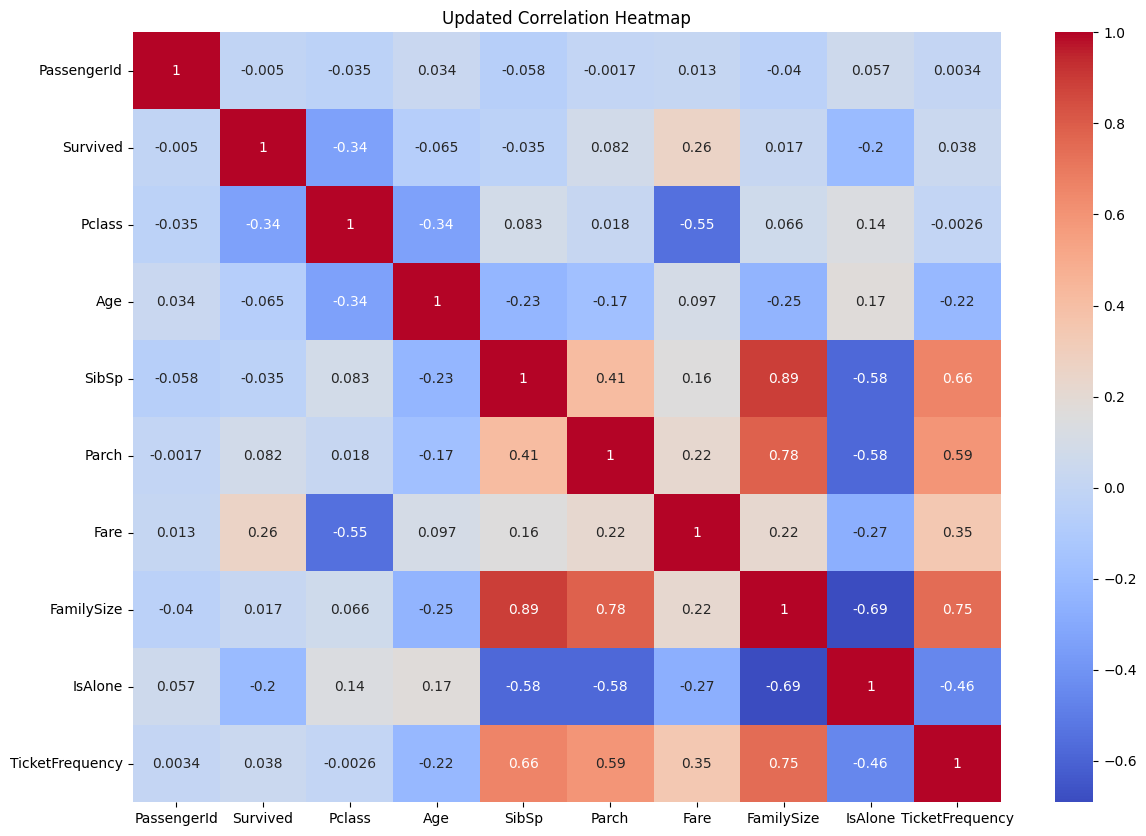

In [42]:
# ================================
# UPDATED CORRELATION HEATMAP
# ================================

numeric_df = train_df.select_dtypes(
    include=["int64", "float64"]
)

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Updated Correlation Heatmap")

plt.show()

# Feature Engineering Summary

The following new features were successfully created:

| Feature | Description |
|----------|-------------|
| FamilySize | Total family members aboard |
| IsAlone | Passenger traveling alone or not |
| Title | Extracted social title |
| AgeGroup | Categorized age ranges |
| FareGroup | Categorized fare ranges |
| TicketFrequency | Shared ticket frequency |
| Deck | Extracted cabin deck |

These features improve the model’s ability to learn survival-related patterns.